In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc3 as pm
import theano
import xarray as xr
from statistics import NormalDist
from PIL import Image
import PIL
import pickle

#####################
#potting with plotly
import plotly.io as pio
import plotly.express as px
pio.renderers.default='browser'

from plotly.subplots import make_subplots
import plotly.graph_objects as go

print(f"Running on PyMC3 v{pm.__version__}")
print(f"Running on PyMC3 v{pm.__version__}")

Running on PyMC3 v3.11.4
Running on PyMC3 v3.11.4


In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

data=pd.read_csv('data_bt_dem.csv')
data=data.rename(columns={"participant": "participant_id"})
data=data.rename(columns={"acc": "response"})


data.head()


,Unnamed: 0,participant_id,index,session,draws,response,confidence_BT,gender,age,pdi,caps,pdi_group,caps_group
0,0,AD20,5,1.0,1.0,1.0,3.019048,0.0,18.0,71.0,154.0,high_pdi,high_caps
1,1,AD20,6,1.0,3.0,1.0,5.952381,0.0,18.0,71.0,154.0,high_pdi,high_caps
2,2,AD20,7,1.0,5.0,1.0,4.980952,0.0,18.0,71.0,154.0,high_pdi,high_caps
3,3,AD20,8,1.0,3.0,1.0,6.980952,0.0,18.0,71.0,154.0,high_pdi,high_caps
4,4,AD20,9,1.0,6.0,1.0,5.971429,0.0,18.0,71.0,154.0,high_pdi,high_caps


In [3]:
#data['response'].replace(0, -1, inplace=True)
from scipy import stats
data['z_draws']=stats.zscore(data['draws'])
data['z_pdi']=stats.zscore(data['pdi'])
data['z_caps']=stats.zscore(data['caps'])


In [4]:
%config InlineBackend.figure_format = 'retina'
az.style.use("arviz-darkgrid")


In [5]:
participant_idx, participant = pd.factorize(data.participant_id)
coords = {
    "participant": participant,
    "obs_id": np.arange(len(data)),
}

n=len(data)
hr_accuracy_bt_tms_draws_x= pm.Model(coords=coords) 
m_acc=data['response'].mean()


with hr_accuracy_bt_tms_draws_x as binomial_regression_model:
    
       # Hyperpriors for group nodes
    mu_a = pm.Normal("mu_a", mu=0.5, sigma=0.5)
    sigma_a = pm.HalfNormal("sigma_a", 0.5)
    mu_b_draws = pm.Normal("mu_b_draws", mu=0.0, sigma=10)
    sigma_b_draws = pm.HalfNormal("sigma_b_draws", 0.5)
    mu_b_tms= pm.Normal("mu_b_tms", mu=0.0, sigma=10)
    sigma_b_tms = pm.HalfNormal("sigma_b_tms", 0.5)
    mu_b_tmsXdraws= pm.Normal("mu_b_tmsXdraws", mu=0.0, sigma=10)
    sigma_b_tmsXdraws = pm.HalfNormal("sigma_b_tmsXdraws", 0.5)
 
    a = pm.Normal("a", mu=mu_a, sigma=sigma_a, dims="participant")

    b_draws= pm.Normal("b_draws", mu=mu_b_draws, sigma=sigma_b_draws, dims="participant")
    
    b_tms= pm.Normal("b_tms", mu=mu_b_tms, sigma=sigma_b_tms, dims="participant")
    
    b_tmsXdraws = pm.Normal("b_tmsXdraws", mu=mu_b_tmsXdraws, sigma=sigma_b_tmsXdraws, dims="participant")


    # Model spec
    acc_like_reg = (a[participant_idx] 
                      +b_draws [participant_idx]* data.z_draws.values                      
                      +b_tms[participant_idx]* data.session
                      +b_tmsXdraws[participant_idx] * data.session * data.z_draws.values
)
    
    p = pm.Deterministic("p", pm.math.invlogit(acc_like_reg))
    
    # Data likelihood
    accuracy_like = pm.Binomial(
        "accuracy_like", n=1, p=p, observed=data.response)
    
    

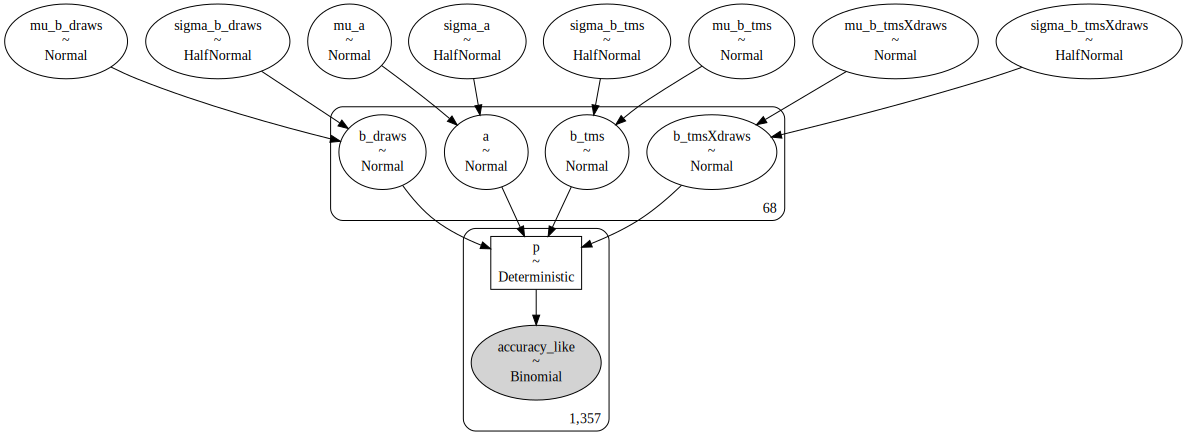

In [6]:
pm.model_to_graphviz(hr_accuracy_bt_tms_draws_x)

In [7]:
with hr_accuracy_bt_tms_draws_x:
     hr_accuracy_bt_tms_draws_x_trace = pm.sample(5000,tune=5000, target_accept=0.9, return_inferencedata=True)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b_tmsXdraws, b_tms, b_draws, a, sigma_b_tmsXdraws, mu_b_tmsXdraws, sigma_b_tms, mu_b_tms, sigma_b_draws, mu_b_draws, sigma_a, mu_a]


/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
Sampling 4 chains for 5_000 tune and 5_000 draw iterations (20_000 + 20_000 draws total) took 918 seconds.
There were 333 divergences after tuning. Increase `target_accept` or reparameterize.
There were 1325 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.765321209201385, but should be

In [8]:
# Save the model
with open('hr_accuracy_bt_tms_draws_x.pkl', 'wb') as file:
    pickle.dump(hr_accuracy_bt_tms_draws_x, file)
    
hr_accuracy_bt_tms_draws_x_trace.to_netcdf('hr_accuracy_bt_tms_draws_x_trace.nc', compress=False)    

'hr_accuracy_bt_tms_draws_x_trace.nc'

In [8]:
# Load the model from the pickled file
with open('hr_accuracy_bt_tms_draws_x.pkl', 'rb') as file:
    hr_accuracy_bt_tms_draws_x = pickle.load(file)

hr_accuracy_bt_tms_draws_x_trace = az.from_netcdf('hr_accuracy_bt_tms_draws_x_trace.nc')


In [9]:
# Calculate the log likelihood using the log_likelihood method of the InferenceData object
log_likelihood = hr_accuracy_bt_tms_draws_x_trace.log_likelihood

# Compute the marginal likelihood (also known as the log pointwise predictive density)
marginal_likelihood = hr_accuracy_bt_tms_draws_x_trace.sum()

# Optionally, you can calculate the effective number of parameters (p_waic)
p_waic = az.waic(hr_accuracy_bt_tms_draws_x_trace).p_waic

# Optionally, you can calculate the Widely Applicable Information Criterion (WAIC)
waic = az.waic(hr_accuracy_bt_tms_draws_x_trace, scale='deviance')

print("Log likelihood:", log_likelihood.draw.mean())
print("Marginal likelihood (Log pointwise predictive density):", marginal_likelihood)
print("Effective number of parameters (p_waic):", p_waic)
print("WAIC:", waic)

/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/arviz/stats/stats.py:1405: UserWarning:

For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details



Log likelihood: <xarray.DataArray 'draw' ()>
array(2499.5)
Marginal likelihood (Log pointwise predictive density): Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> observed_data
Effective number of parameters (p_waic): 40.829333542324314
WAIC: Computed from 20000 by 1357 log-likelihood matrix

              Estimate       SE
deviance_waic   568.49    42.57
p_waic           40.83        -

There has been a warning during the calculation. Please check the results.


/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/arviz/stats/stats.py:1405: UserWarning:

For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details



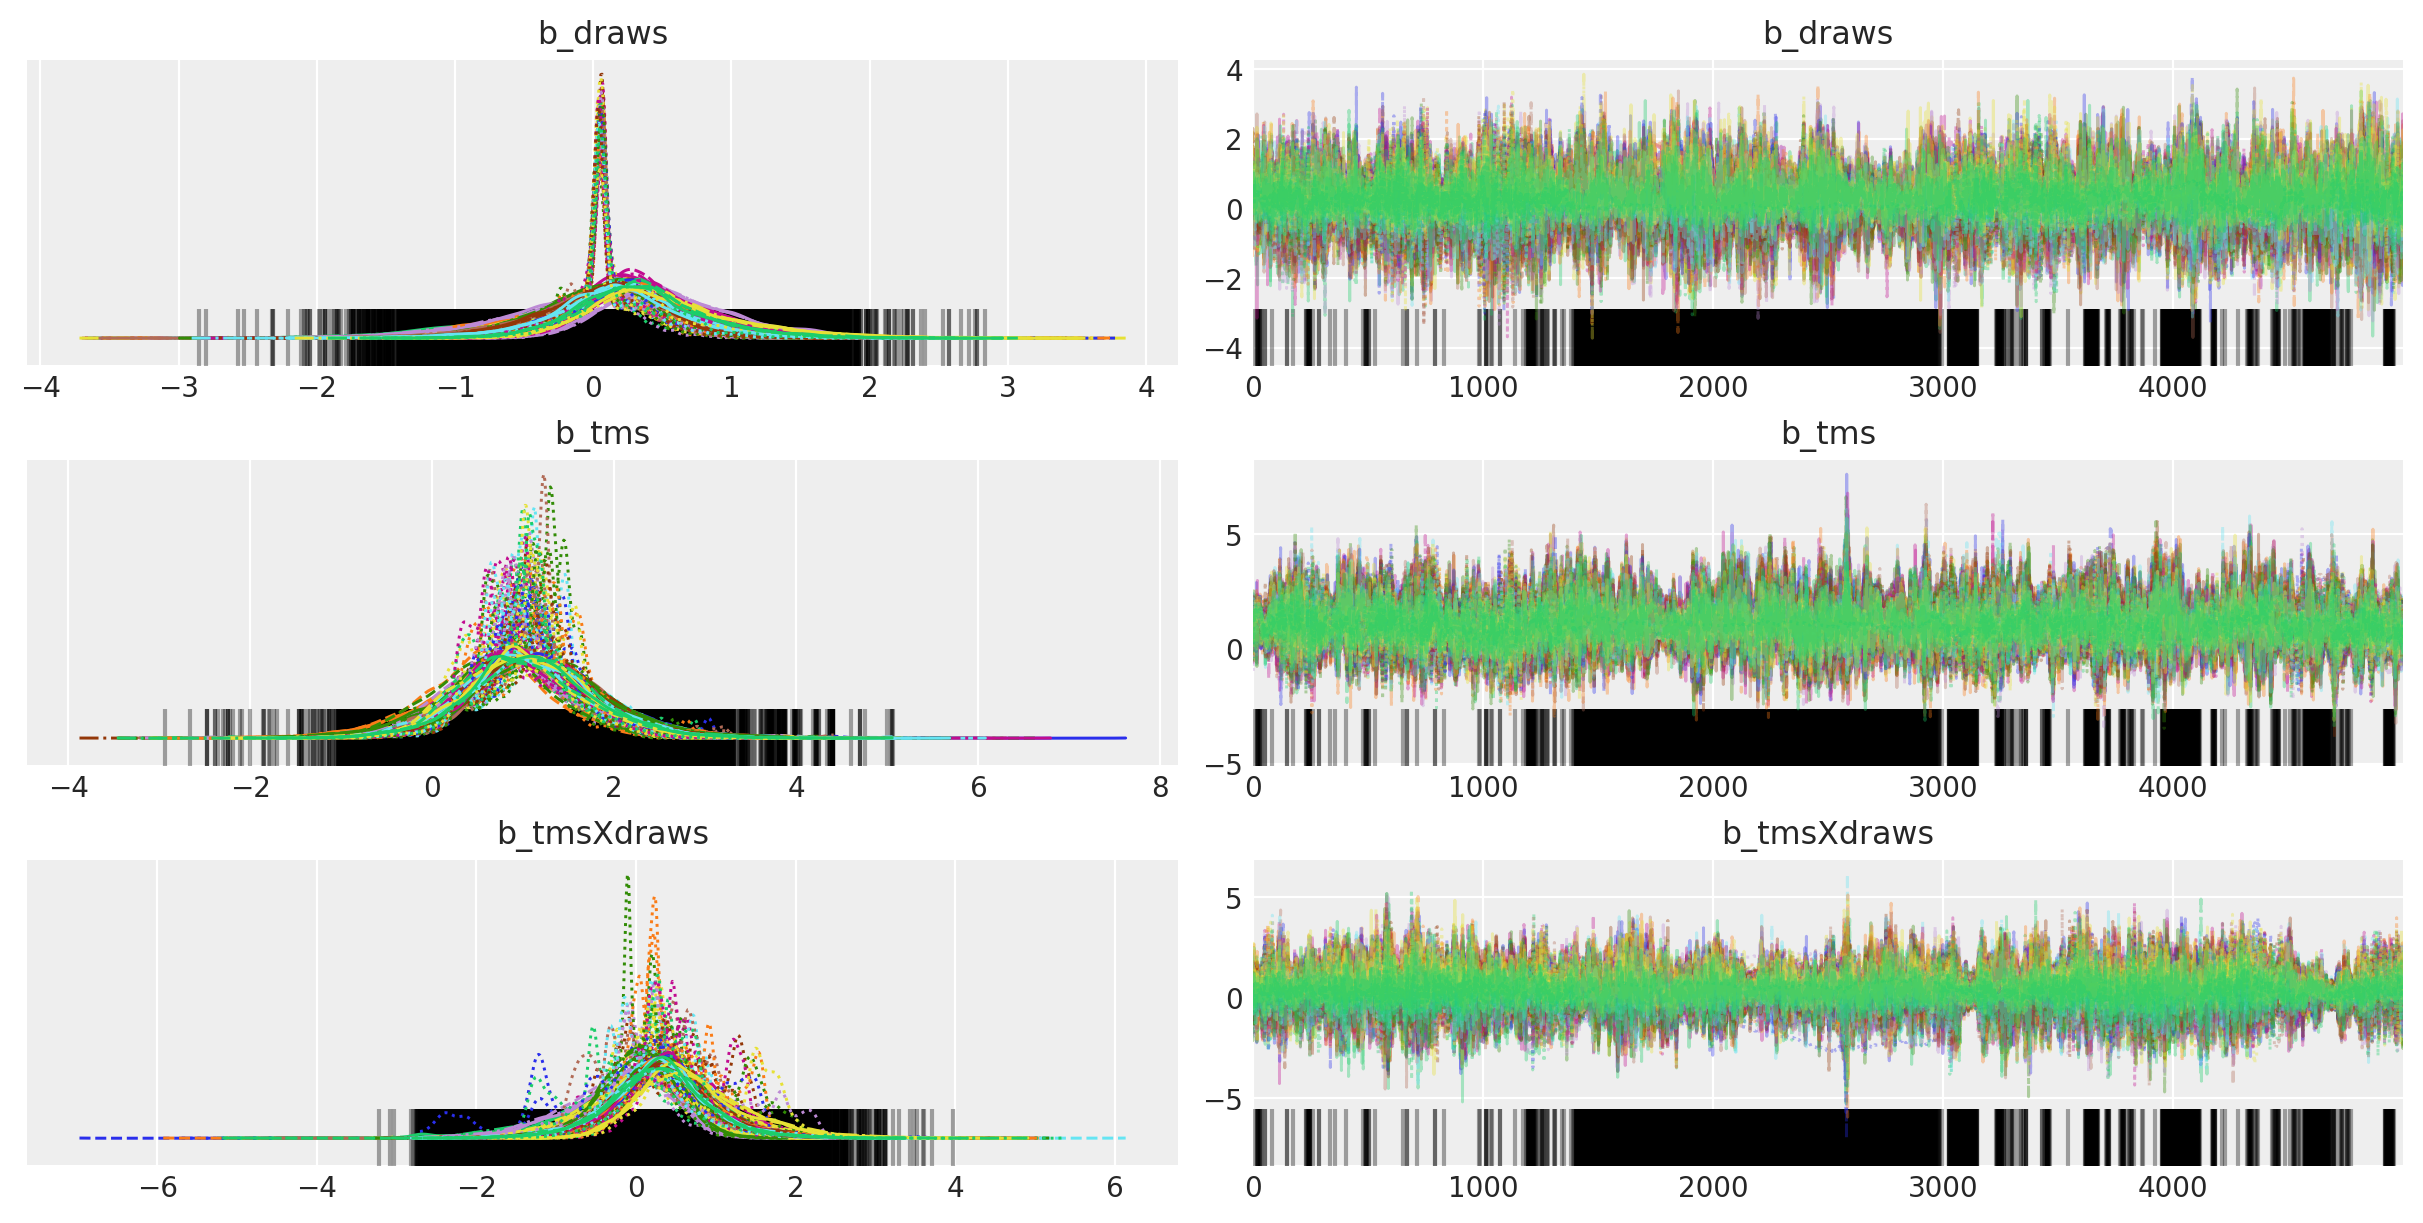

In [11]:
az.plot_trace(hr_accuracy_bt_tms_draws_x_trace, var_names=["b_draws", "b_tms","b_tmsXdraws"], coords={"participant": participant});


In [12]:
stat_acc_reg=pm.summary(hr_accuracy_bt_tms_draws_x_trace, var_names=["mu_b_draws", "mu_b_tms","mu_b_tmsXdraws"]);

stat_acc_reg

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_b_draws,0.179,0.239,-0.273,0.639,0.010,0.008,603.0,1368.0,1.01
mu_b_tms,1.063,0.465,0.225,1.975,0.021,0.015,490.0,560.0,1.04
mu_b_tmsXdraws,0.286,0.340,-0.361,0.945,0.012,0.008,861.0,1587.0,1.03


=== Probability Summary for Each Participant ===
   p_session0_mean  p_session0_low  p_session0_high  p_session1_mean  \
0         0.705305        0.705305         0.705305         0.979183   

   p_session1_low  p_session1_high  delta_mean  delta_low  delta_high  
0        0.968237         0.987267    0.273878   0.262932    0.281962  

=== Population-Level Probability Effect ===
{'p0_mean': 0.7053048694950502, 'p0_CI': (0.7053048694950502, 0.7053048694950502), 'p1_mean': 0.9791832186998354, 'p1_CI': (0.9682370455420519, 0.9872667840445857), 'delta_mean': 0.27387834920478515, 'delta_CI': (0.2629321760470017, 0.28196191454953545)}


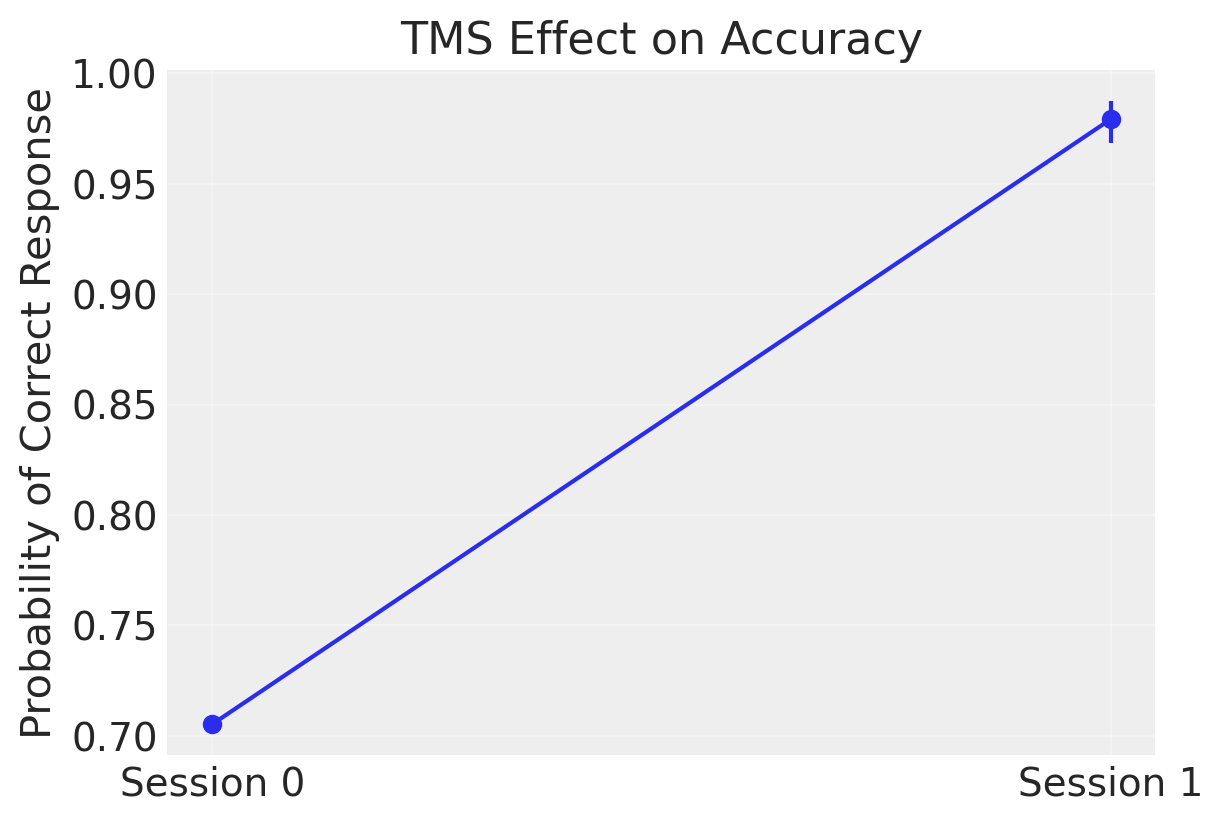

In [23]:

from scipy.special import expit as invlogit
import matplotlib.pyplot as plt

# -------------------------------
# 1. Extract posterior samples
# -------------------------------
import numpy as np

posterior = hr_accuracy_bt_tms_trace.posterior  # shorthand
"""
# Collect all variables matching a[0], a[1], …
a_names = [v for v in posterior.data_vars if v.startswith("a[")]

# Stack them into a 3D array (chain, draw, participant)
a_post = np.stack([posterior[v].values for v in a_names], axis=-1)
# shape: (chain, draw, n_participants)

a_post = a_post.reshape(-1, a_post.shape[-1])   # (samples, participants)
a_mean_post = a_post.mean(axis=1)  # (samples,)


# -------------------------------
# 2. Compute probabilities
# -------------------------------
# We assume session ∈ {0,1}
# Baseline probability: session = 0
p0_mean = invlogit(a_mean_post)
"""
a_post = hr_accuracy_bt_tms_trace.posterior["a"].values.reshape(-1)
a_post = a_post.reshape(-1, a_post.shape[-1])   # (samples, participants)
a_mean_post = a_post.mean(axis=1)  # (samples,)

b_post = hr_accuracy_bt_tms_trace.posterior["b_tms"].values.reshape(-1)

"""
print({
    "p0_mean": p0_mean.mean(),
    "p1_mean": p1_mean.mean(),
    "delta_mean": delta.mean(),
    "delta_low": np.percentile(delta, 2.5),
    "delta_high": np.percentile(delta, 97.5)
})
"""
# Session = 1 probability
p1 = invlogit(a_mean_post + b_post[:, None])
p0 = invlogit(a_mean_post)

# Change in probability
delta_p = p1 - p0

# -------------------------------
# 3. Summaries per participant
# -------------------------------
summary_df = pd.DataFrame({
    "p_session0_mean": p0.mean(axis=0),
    "p_session0_low":  np.percentile(p0, 2.5, axis=0),
    "p_session0_high": np.percentile(p0, 97.5, axis=0),

    "p_session1_mean": p1.mean(axis=0),
    "p_session1_low":  np.percentile(p1, 2.5, axis=0),
    "p_session1_high": np.percentile(p1, 97.5, axis=0),

    "delta_mean": delta_p.mean(axis=0),
    "delta_low":  np.percentile(delta_p, 2.5, axis=0),
    "delta_high": np.percentile(delta_p, 97.5, axis=0),
})

print("=== Probability Summary for Each Participant ===")
print(summary_df)

# -------------------------------
# 4. Population-level average effect
# -------------------------------
pop_avg = {
    "p0_mean": p0.mean(),
    "p0_CI": (np.percentile(p0, 2.5), np.percentile(p0, 97.5)),

    "p1_mean": p1.mean(),
    "p1_CI": (np.percentile(p1, 2.5), np.percentile(p1, 97.5)),

    "delta_mean": delta_p.mean(),
    "delta_CI": (np.percentile(delta_p, 2.5), np.percentile(delta_p, 97.5)),
}

print("\n=== Population-Level Probability Effect ===")
print(pop_avg)


# -------------------------------
# 5. Plot: Population effect
# -------------------------------
plt.figure(figsize=(6,4))

plt.errorbar(
    [0,1],
    [p0.mean(), p1.mean()],
    yerr=[
        [p0.mean()-np.percentile(p0, 2.5), p1.mean()-np.percentile(p1, 2.5)],
        [np.percentile(p0, 97.5)-p0.mean(), np.percentile(p1, 97.5)-p1.mean()],
    ],
    fmt="o-"
)

plt.xticks([0,1], ["Session 0", "Session 1"])
plt.ylabel("Probability of Correct Response")
plt.title("TMS Effect on Accuracy")
plt.grid(alpha=0.3)

plt.show()


In [38]:
# Extract posterior samples
posterior_samples = data.response
# Define color mapping for ideology groups
color_map = {"Liberals": "blue", "Conservatives": "red"}

# Compute group-level predicted probabilities
fig = go.Figure()

for pol_category, pol_value in zip(["Liberals", "Conservatives"], [-1, 1]):  # Left = Liberals, Right = Conservatives
    # Compute mean regression coefficients across participants
    a_mean = np.mean(a_samples)  # Overall intercept mean
    b_threat_mean = np.mean(b_threat_samples)
    b_pol_mean = np.mean(b_pol_samples)
    b_polXthreat_mean = np.mean(b_polXthreat_samples)

    # Compute probability using logistic function
    p_pred = 1 / (1 + np.exp(-(a_mean 
                               + b_threat_mean * threat_range
                               + b_pol_mean * pol_value
                               + b_polXthreat_mean * pol_value * threat_range)))

    # Add line to plot with color based on ideology
    fig.add_trace(go.Scatter(
        x=threat_range, y=p_pred,
        mode="lines",
        name=pol_category,
        line=dict(color=color_map[pol_category])
    ))

# Customize layout
fig.update_layout(
    title="Effect of Threat Rating on Probability by Ideology",
    xaxis_title="Threat Rating (z_threat_rating)",
    yaxis_title="Predicted Probability",
    template="plotly_white"
)

fig.show()

In [15]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

# Define number of bins
num_bins = 2  
data["threat_bin"] = pd.cut(data.threat_rating, bins=num_bins, labels=False)  # Bin threat rating

# Group data by ideology (Liberals/Conservatives) and threat_bin, then compute mean accuracy
data["pol_category"] = np.where(data.z_pol_rating < 0, "Liberals", "Conservatives")

accuracy_means = data.groupby(["pol_category", "threat_bin"]).agg(
    mean_accuracy=("response", "mean"),
    mean_threat=("threat_rating", "mean")  # Get average threat rating per bin
).reset_index()

# Define color mapping
color_map = {"Liberals": "blue", "Conservatives": "red"}

# Create figure
fig = go.Figure()

# Plot accuracy trends for each ideology group
for pol_category in ["Liberals", "Conservatives"]:
    subset = accuracy_means[accuracy_means.pol_category == pol_category]

    fig.add_trace(go.Scatter(
        x=subset.mean_threat, y=subset.mean_accuracy,
        mode="markers+lines",
        name=pol_category,
        line=dict(color=color_map[pol_category])
    ))

# Customize layout
fig.update_layout(
    title="Actual Accuracy by Threat Rating and Ideology",
    xaxis_title="Threat Rating",
    yaxis_title="Mean Accuracy",
    template="plotly_white"
)

fig.show()


In [46]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

# Define number of bins
num_bins = 5  
data["threat_bin"] = pd.cut(data.z_threat_rating, bins=num_bins, labels=False)  # Bin threat rating

# Group data by ideology (Liberals/Conservatives) and threat_bin, then compute mean accuracy
data["pol_category"] = np.where(data.z_pol_rating < 0, "Liberals", "Conservatives")

# Compute average accuracy and threat rating per participant
participant_means = data.groupby(["participant_id", "pol_category"]).agg(
    mean_accuracy=("response", "mean"),
    mean_threat=("z_threat_rating", "mean")
).reset_index()

# Compute binned means for trend lines
accuracy_means = data.groupby(["pol_category", "threat_bin"]).agg(
    mean_accuracy=("response", "mean"),
    mean_threat=("z_threat_rating", "mean")  # Get average threat rating per bin
).reset_index()

# Define color mapping
color_map = {"Liberals": "blue", "Conservatives": "red"}

# Create figure
fig = go.Figure()

# Plot individual participant averages
for pol_category in ["Liberals", "Conservatives"]:
    subset = participant_means[participant_means.pol_category == pol_category]

    fig.add_trace(go.Scatter(
        x=subset.mean_threat, y=subset.mean_accuracy,
        mode="markers",
        name=f"{pol_category} (Participants)",
        marker=dict(color=color_map[pol_category], size=8, opacity=0.7),
        legendgroup=pol_category,
        showlegend=True
    ))

# Plot accuracy trends for each ideology group
for pol_category in ["Liberals", "Conservatives"]:
    subset = accuracy_means[accuracy_means.pol_category == pol_category]

    fig.add_trace(go.Scatter(
        x=subset.mean_threat, y=subset.mean_accuracy,
        mode="lines",
        name=f"{pol_category} (Mean Trend)",
        line=dict(color=color_map[pol_category], width=2),
        legendgroup=pol_category,
        showlegend=True
    ))

# Customize layout
fig.update_layout(
    title="Participant-Level Accuracy vs. Threat Rating by Ideology",
    xaxis_title="Mean Threat Rating (per Participant)",
    yaxis_title="Mean Accuracy (per Participant)",
    template="plotly_white"
)

fig.show()


In [20]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

# Define bins for z_threat_rating (same as before)
num_threat_bins = 4  
data["threat_bin"] = pd.cut(data.threat_rating, bins=num_threat_bins,include_lowest=True, labels=False)

# Define 5 bins for z_pol_rating (Extreme Liberal to Extreme Conservative)
num_pol_bins = 4
data["pol_bin"] = pd.cut(
    data.z_pol_rating, 
    bins=num_pol_bins,
    include_lowest=True,
    labels=["Extreme Liberal", 
            "Liberal", 
            #"Moderate", 
            "Conservative", 
            "Extreme Conservative"]
)

# Compute binned means for trend lines (group by pol_bin and threat_bin)
accuracy_means = data.groupby(["pol_bin", "threat_bin"]).agg(
    mean_accuracy=("response", "mean"),
    mean_threat=("threat_rating", "mean")  # Get avg threat per bin
).reset_index()

# Define color mapping for the 5 ideological bins
color_map = {
    "Extreme Liberal": "red",
    "Liberal": "pink",
    #"Moderate": "gray",
    "Conservative": "lightblue",
    "Extreme Conservative": "blue"
}

# Create figure
fig = go.Figure()

# Plot accuracy trends for each ideology bin
for pol_bin in color_map.keys():
    subset = accuracy_means[accuracy_means.pol_bin == pol_bin]

    fig.add_trace(go.Scatter(
        x=subset.mean_threat, y=subset.mean_accuracy,
        mode="lines",
        name=f"{pol_bin}",
        line=dict(color=color_map[pol_bin], width=2),
        legendgroup=pol_bin,
        showlegend=True
    ))

# Customize layout
fig.update_layout(
    title="Accuracy vs. Threat Rating by Political Orientation",
    xaxis_title="Mean Threat Rating",
    yaxis_title="Mean Accuracy",
    template="plotly_white"
)

fig.show()


In [23]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

# Define bins for z_threat_rating (same as before)
num_threat_bins =4  
data["threat_bin"] = pd.qcut(data.threat_rating, q=num_threat_bins, labels=False)

# Define 5 bins for z_pol_rating (Extreme Liberal to Extreme Conservative)
num_pol_bins = 4
data["pol_bin"] = pd.qcut(
    data.z_pol_rating, 
    q=num_pol_bins,
    labels=["Extreme Liberal", 
            "Liberal", 
            #"Moderate", 
            "Conservative", 
            "Extreme Conservative"]
)

# Compute binned means for trend lines (group by pol_bin and threat_bin)
accuracy_means = data.groupby(["pol_bin", "threat_bin"]).agg(
    mean_accuracy=("response", "mean"),
    mean_threat=("threat_rating", "mean")  # Get avg threat per bin
).reset_index()

# Define color mapping for the 5 ideological bins
color_map = {
    "Extreme Liberal": "red",
    "Liberal": "pink",
    #"Moderate": "gray",
    "Conservative": "lightblue",
    "Extreme Conservative": "blue"
}

# Create figure
fig = go.Figure()

# Plot accuracy trends for each ideology bin
for pol_bin in color_map.keys():
    subset = accuracy_means[accuracy_means.pol_bin == pol_bin]

    fig.add_trace(go.Scatter(
        x=subset.mean_threat, y=subset.mean_accuracy,
        mode="lines",
        name=f"{pol_bin}",
        line=dict(color=color_map[pol_bin], width=2),
        legendgroup=pol_bin,
        showlegend=True
    ))

# Customize layout
fig.update_layout(
    title="Accuracy vs. Threat Rating by Political Orientation",
    xaxis_title="Mean Threat Rating",
    yaxis_title="Mean Accuracy",
    template="plotly_white"
)

fig.show()


In [21]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

# Define bins for z_threat_rating
num_threat_bins = 4  
data["threat_bin"] = pd.qcut(data.threat_rating, q=num_threat_bins, labels=False)

num_threat_bins_part = 2  
data["threat_bin_part"] = pd.qcut(data.threat_rating, q=num_threat_bins_part, labels=False)

# Define 4 bins for z_pol_rating (Extreme Liberal to Extreme Conservative)
num_pol_bins = 4
data["pol_bin"] = pd.qcut(
    data.z_pol_rating, 
    q=num_pol_bins,
    labels=["Extreme Liberal", "Liberal", "Conservative", "Extreme Conservative"]
)

# Ensure pol_bin is treated as a string to avoid categorical issues
data["pol_bin"] = data["pol_bin"].astype(str)

# Compute binned means per participant
accuracy_means = data.groupby(["participant_id", "pol_bin", "threat_bin_part"]).agg(
    mean_accuracy=("response", "mean"),
    mean_threat=("threat_rating", "mean")  # Get avg threat per bin
).reset_index()

# Compute binned means per participant
accuracy_means_group = data.groupby(["participant_id", "pol_bin", "threat_bin"]).agg(
    mean_accuracy=("response", "mean"),
    mean_threat=("threat_rating", "mean")  # Get avg threat per bin
).reset_index()

# Define color mapping for political bins
color_map = {
    "Extreme Liberal": "red",
    "Liberal": "pink",
    "Conservative": "lightblue",
    "Extreme Conservative": "blue"
}

# Create figure
fig = go.Figure()

# **Get each participant's pol_bin before plotting**  
participant_bins = data.groupby("participant_id")["pol_bin"].agg(pd.Series.mode).to_dict()

# Plot accuracy trends for each participant, colored by their political bin
for participant_id in accuracy_means.participant_id.unique():
    subset = accuracy_means[accuracy_means.participant_id == participant_id]

    # Get participant's political bin (from precomputed dictionary)
    pol_bin = participant_bins.get(participant_id, "Unknown")  

    # Ensure pol_bin is a valid key (fallback to gray)
    line_color = color_map.get(pol_bin, "gray")

    fig.add_trace(go.Scatter(
        x=subset.mean_threat, y=subset.mean_accuracy,
        mode="lines",
        name=f"Participant {participant_id} ({pol_bin})",
        line=dict(color=line_color, width=2, dash="dot"),  # Semi-transparent dotted lines
        legendgroup=pol_bin,
        showlegend=False  # Hide individual participant legend entries
    ))

# Add averaged trend lines per political bin for clarity
for pol_bin, color in color_map.items():
    subset = accuracy_means_group[accuracy_means_group.pol_bin == pol_bin].groupby("threat_bin").mean().reset_index()

    fig.add_trace(go.Scatter(
        x=subset.mean_threat, y=subset.mean_accuracy,
        mode="lines",
        name=f"{pol_bin} (Avg)",
        line=dict(color=color, width=6),
        legendgroup=pol_bin,
        showlegend=True
    ))

# Customize layout
fig.update_layout(
    title="Accuracy vs. Threat Rating (Colored by Political Bin)",
    xaxis_title="Mean Threat Rating",
    yaxis_title="Mean Accuracy",
    template="plotly_white"
)

fig.show()


/var/folders/cz/jbpqkvc936gc0lrwm6908lsh0000gn/T/ipykernel_11793/4099805168.py:70: FutureWarning:

The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.

/var/folders/cz/jbpqkvc936gc0lrwm6908lsh0000gn/T/ipykernel_11793/4099805168.py:70: FutureWarning:

The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.

/var/folders/cz/jbpqkvc936gc0lrwm6908lsh0000gn/T/ipykernel_11793/4099805168.py:70: FutureWarning:

The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.

/var/folders/cz/jbpqkvc936gc0lrwm6